# 🚚 Freight Cost Prediction - EDA

## 📌 Objective
Analyze Olist e-commerce dataset to understand factors affecting freight cost.

## 🎯 Goal
- Identify key features
- Prepare data for ML model
- Perform exploratory data analysis (EDA)

In [2]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
## Load Dataset

orders = pd.read_csv("../data/olist_orders_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")

print(orders.shape, items.shape, products.shape)
orders.head()

(99441, 8) (112650, 7) (32951, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
## Merge Dataset

df = orders.merge(items, on="order_id")
df = df.merge(products, on="product_id")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [5]:
df.shape

(112650, 22)

In [6]:
df.shape

(112650, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   order_item_id                  112650 non-null  int64  
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

In [8]:
## Missing Values

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

order_delivered_customer_date    2454
product_description_lenght       1603
product_category_name            1603
product_name_lenght              1603
product_photos_qty               1603
order_delivered_carrier_date     1194
product_width_cm                   18
product_height_cm                  18
product_length_cm                  18
product_weight_g                   18
order_approved_at                  15
dtype: int64

In [9]:
## Feature Engineering

# Convert to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Delivery time
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Volume
df['volume'] = (
    df['product_length_cm'] *
    df['product_height_cm'] *
    df['product_width_cm']
)

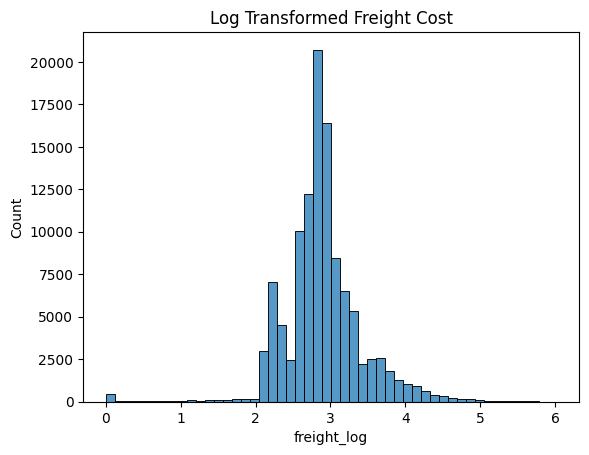

In [10]:
## Log Transformation

df['freight_log'] = np.log1p(df['freight_value'])

plt.figure()
sns.histplot(df['freight_log'], bins=50)
plt.title("Log Transformed Freight Cost")
plt.show()

Feature Relationships

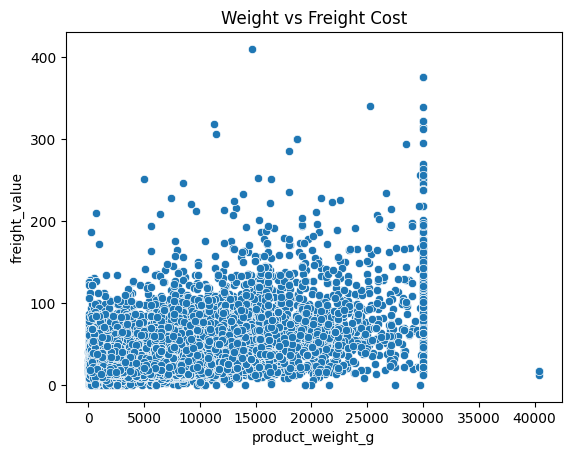

In [11]:
## Weight vs Freight Cost

sns.scatterplot(x=df['product_weight_g'], y=df['freight_value'])
plt.title("Weight vs Freight Cost")
plt.show()

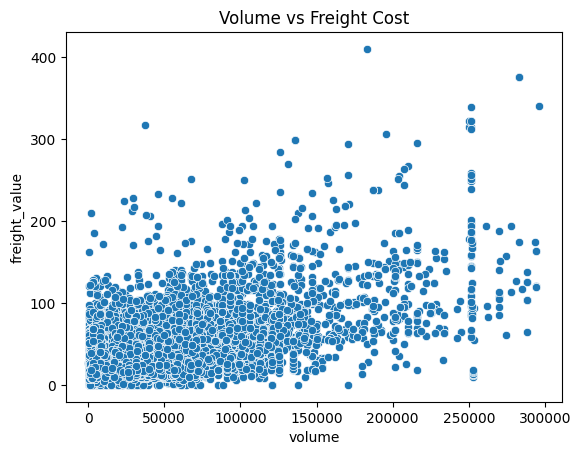

In [12]:
## Volume vs Freight Cost

sns.scatterplot(x=df['volume'], y=df['freight_value'])
plt.title("Volume vs Freight Cost")
plt.show()

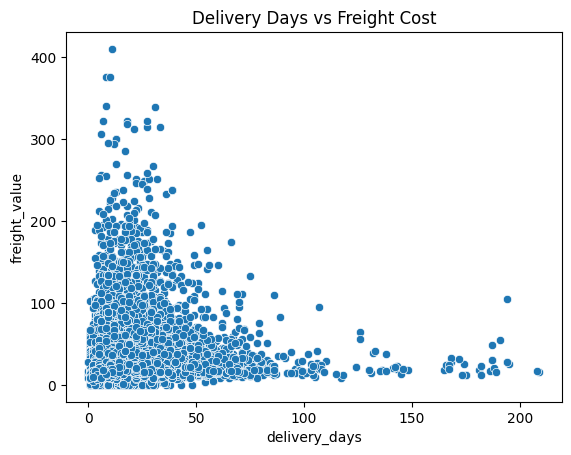

In [13]:
## Delivery Days vs Cost

sns.scatterplot(x=df['delivery_days'], y=df['freight_value'])
plt.title("Delivery Days vs Freight Cost")
plt.show()

Advanced Visualizations

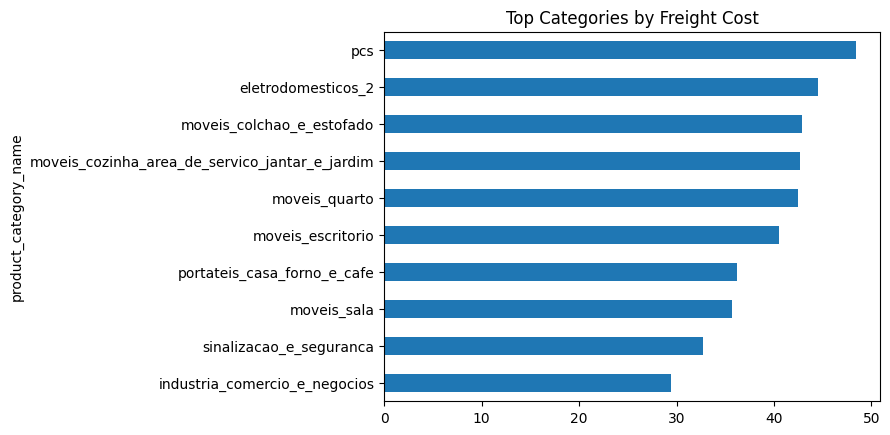

In [15]:
## Top Categories

top_cat = df.groupby('product_category_name')['freight_value'].mean().sort_values().tail(10)

top_cat.plot(kind='barh')
plt.title("Top Categories by Freight Cost")
plt.show()

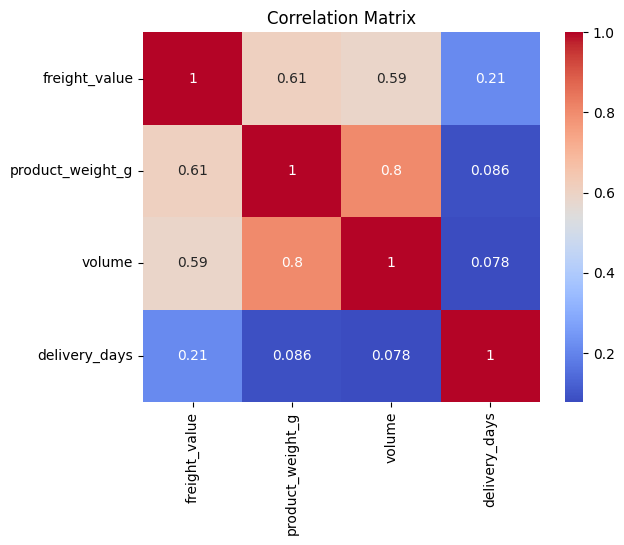

In [16]:
## Correlation Heatmap

corr = df[['freight_value', 'product_weight_g', 'volume', 'delivery_days']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

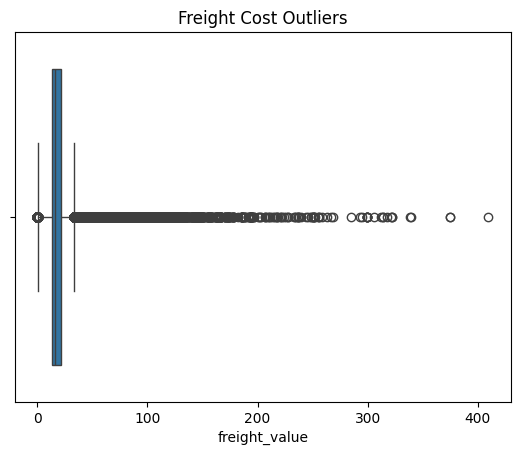

In [17]:
## Boxplot (Outliers)

sns.boxplot(x=df['freight_value'])
plt.title("Freight Cost Outliers")
plt.show()


In [18]:
## Feature Importance Insight (Manual)

df[['freight_value', 'product_weight_g', 'volume', 'delivery_days']].corr()['freight_value'].sort_values()


delivery_days       0.214631
volume              0.587270
product_weight_g    0.610420
freight_value       1.000000
Name: freight_value, dtype: float64

In [19]:
## Data Cleaning

# Drop missing target
df = df.dropna(subset=['freight_value'])

# Remove extreme outliers (optional)
df = df[df['freight_value'] < df['freight_value'].quantile(0.99)]

In [20]:
## . Final Dataset

features = df[['price', 'product_weight_g', 'volume', 'delivery_days']]
target = df['freight_log']

features.head()

,price,product_weight_g,volume,delivery_days
0,29.99,500.0,1976.0,8.0
1,118.70,400.0,4693.0,13.0
2,159.90,420.0,9576.0,9.0
3,45.00,450.0,6000.0,13.0
4,19.90,250.0,11475.0,2.0


## 📊 Key Insights

- Freight cost strongly depends on product weight and volume
- Delivery time has moderate impact
- Data is highly skewed → log transformation improves modeling
- Certain product categories have consistently higher shipping costs
- Outliers exist and need handling for better model performance